In [1]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler


**Bock, R. (2004). MAGIC Gamma Telescope [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52C8B.**

Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope

**Dataset Characteristics**
Multivariate

**Associated Tasks**
Classification

**Feature Type**
Real

**Instances**
19020

**Features**
10


In [2]:
cols = ["fLength", "fWidth", "fSize","fConc","fConc1","fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"];
df = pd.read_csv("magic04.data",names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
df["class"] = (df["class"] == "g").astype(int)

In [4]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


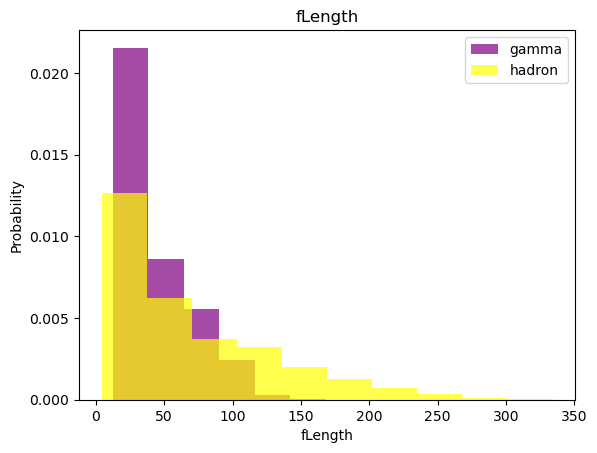

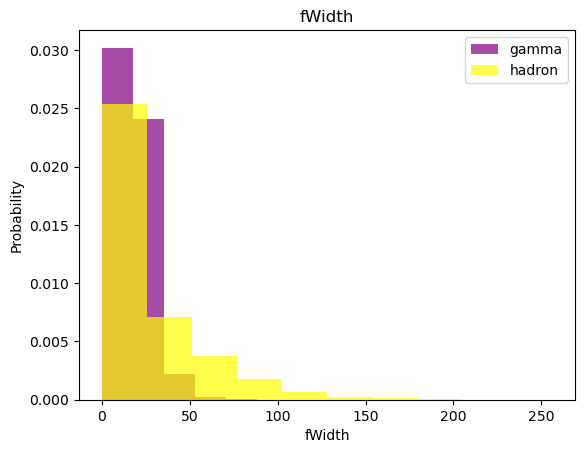

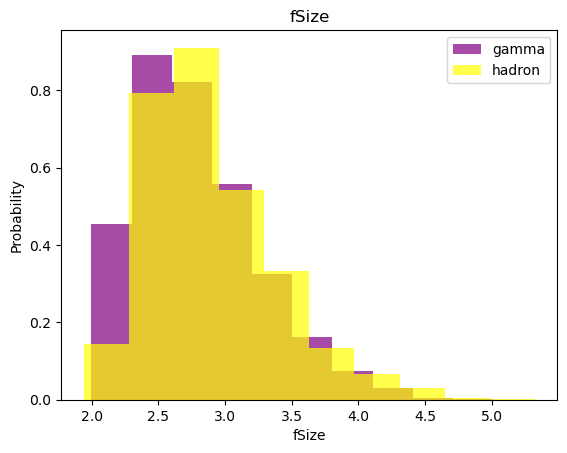

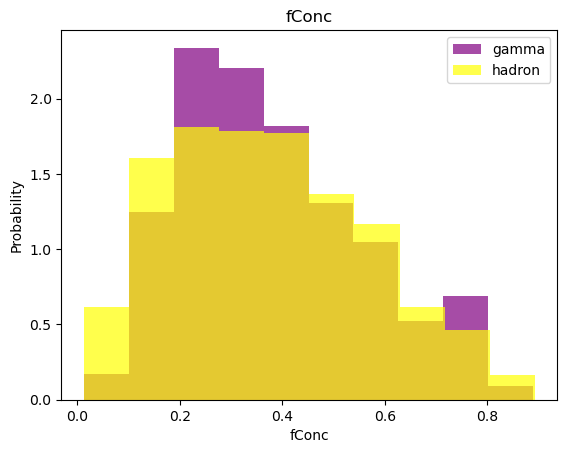

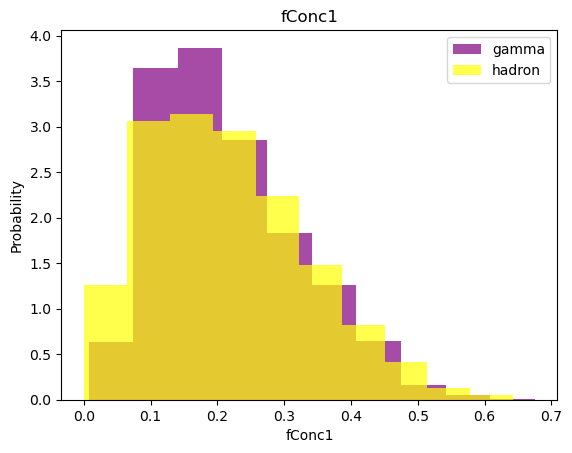

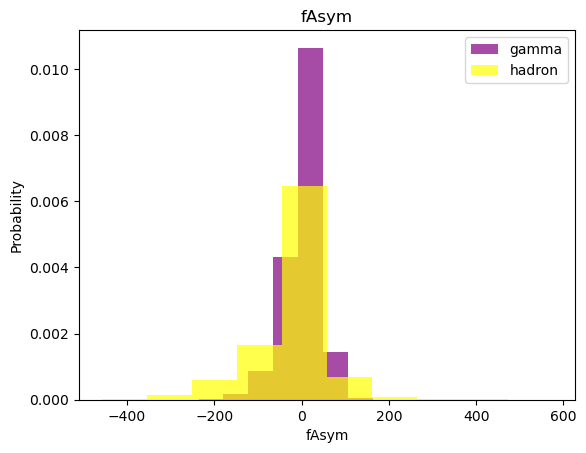

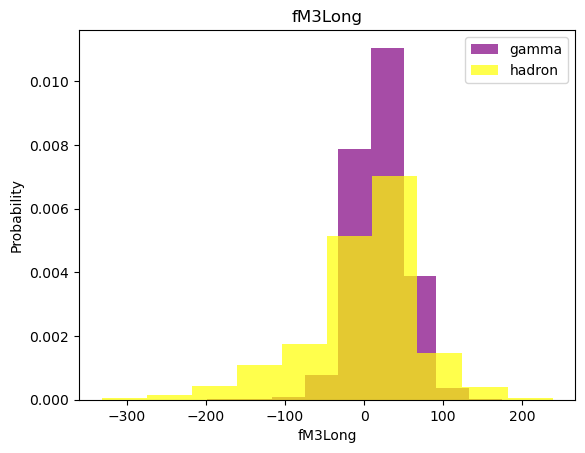

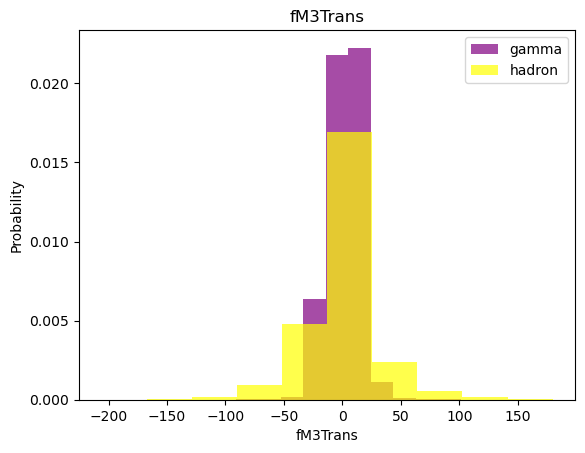

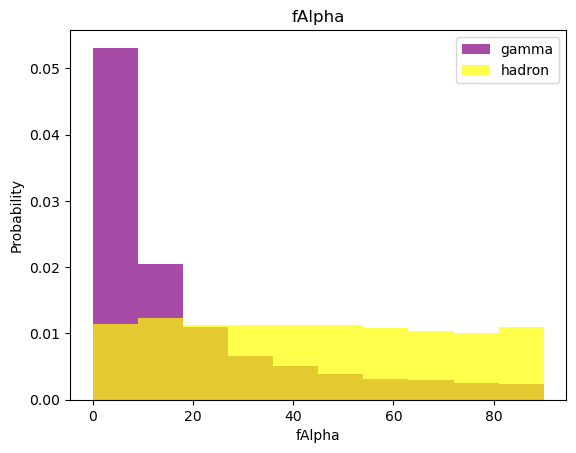

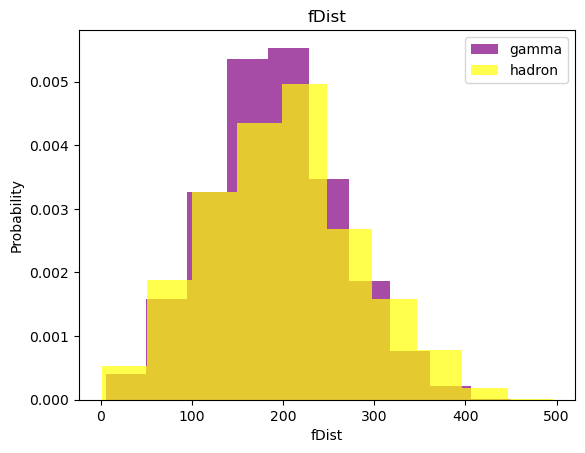

In [5]:
for label in cols[:-1]:
    plt.hist(df[df["class"]==1][label], color="purple", label="gamma", alpha=0.7, density=True)
    plt.hist(df[df["class"]==0][label], color="yellow", label="hadron",alpha=0.7, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [6]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

c:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [7]:
train

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
7361,70.4771,24.1708,3.0459,0.2420,0.1498,-77.2380,53.6032,18.3760,4.0389,262.8750,1
12083,44.3893,17.5785,2.7941,0.3454,0.1839,5.5836,39.0851,-14.7831,0.0840,187.9530,1
10054,35.0575,19.9323,2.8876,0.2876,0.1483,29.6089,30.2589,5.0611,1.2730,187.0370,1
12110,31.8861,15.6996,2.5145,0.4434,0.2339,18.5376,28.5424,12.9482,19.6120,146.4540,1
13857,21.4763,10.3156,2.3666,0.7288,0.3861,15.5219,18.6448,-2.4377,33.5626,263.1362,0
...,...,...,...,...,...,...,...,...,...,...,...
3541,22.0396,16.2619,2.5575,0.5097,0.3144,8.6338,18.1957,14.5208,31.0600,230.9240,1
11161,77.6560,37.4877,3.4837,0.2459,0.1624,-2.7498,51.5182,-24.5590,1.2130,358.4090,1
10526,79.5783,20.2347,2.9125,0.2691,0.1352,-79.2227,46.6966,-16.1247,0.6007,250.4460,1
9357,78.6393,16.8030,3.0060,0.2120,0.1119,95.9530,53.5097,-11.4669,2.2610,233.2700,1


In [8]:
print(len(train[train["class"]==1])) # gamma
print(len(train[train["class"]==0])) # hadron

7364
4048


In [9]:
def scale_dataset(dataframe, oversample = False):
    X = dataframe[cols[:-1]].values
    y = dataframe[cols[-1]].values

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1,1))))

    return data, X, y


In [10]:
train, X_train, y_train = scale_dataset(train, oversample=True)

In [11]:
len(y_train)

14728

In [12]:
sum(y_train==1)  # gamma

np.int64(7364)

In [13]:
sum(y_train==0)  # hadron

np.int64(7364)

In [14]:
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

**KNN: K-Nearest Neighbours**


In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

**k=3**

In [35]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [36]:
y_pred = knn_model.predict(X_test)

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.74      0.73      1330
           1       0.86      0.85      0.86      2474

    accuracy                           0.81      3804
   macro avg       0.79      0.80      0.79      3804
weighted avg       0.81      0.81      0.81      3804



In [38]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

Accuracy: 0.8123



In [39]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 983  347]
 [ 367 2107]]


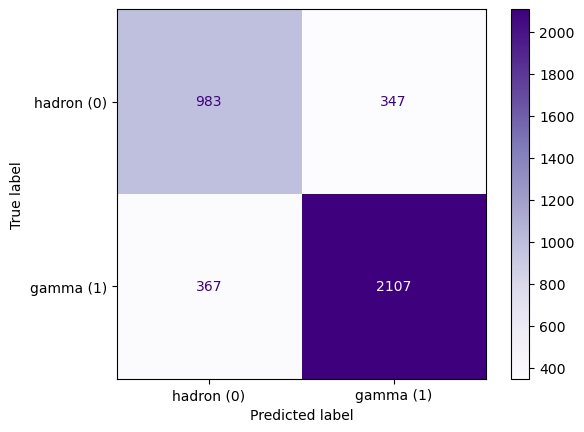

In [40]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["hadron (0)", "gamma (1)"])
disp.plot(cmap="Purples") 
plt.show()

**k=5**

In [41]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
y_pred = knn_model.predict(X_test)

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.72      0.73      1330
           1       0.85      0.86      0.86      2474

    accuracy                           0.81      3804
   macro avg       0.79      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



In [44]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 961  369]
 [ 346 2128]]


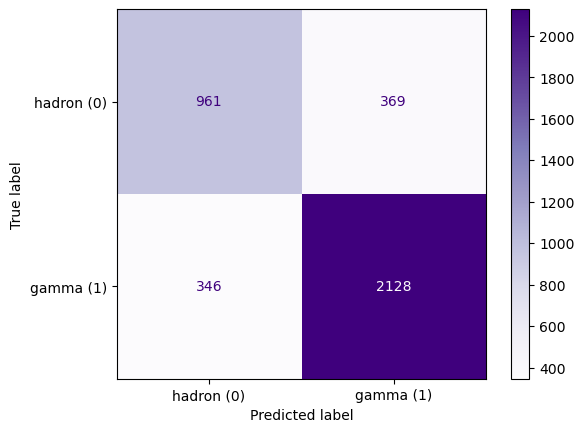

In [45]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["hadron (0)", "gamma (1)"])
disp.plot(cmap="Purples") 
plt.show()